Predict Production using features like Area, Crop, Season, etc.

In [1]:
# importing the necessary libraries
import  numpy as np
import  matplotlib.pyplot as plt
import  pandas as pd
import  seaborn as sns


In [2]:
# loading the dataset
df=pd.read_csv('crop_production.csv')
df.head()

,State_Name,District_Name,Crop_Year,Season,Crop,Area,Production
0,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Arecanut,1254.0,2000.0
1,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Other Kharif pulses,2.0,1.0
2,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Rice,102.0,321.0
3,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Banana,176.0,641.0
4,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Cashewnut,720.0,165.0


In [3]:
# preprocessing the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 246091 entries, 0 to 246090
Data columns (total 7 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   State_Name     246091 non-null  object 
 1   District_Name  246091 non-null  object 
 2   Crop_Year      246091 non-null  int64  
 3   Season         246091 non-null  object 
 4   Crop           246091 non-null  object 
 5   Area           246091 non-null  float64
 6   Production     242361 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 13.1+ MB


In [4]:
# checking for null values
df.isnull().sum()

State_Name          0
District_Name       0
Crop_Year           0
Season              0
Crop                0
Area                0
Production       3730
dtype: int64

In [5]:
# handling the null values
df['Production'].fillna(df['Production'].mean(), inplace=True)


C:\Users\NITHISHA REDDY\AppData\Local\Temp\ipykernel_6408\1749085049.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Production'].fillna(df['Production'].mean(), inplace=True)


In [6]:
# checking for null values
df.isnull().sum()

State_Name       0
District_Name    0
Crop_Year        0
Season           0
Crop             0
Area             0
Production       0
dtype: int64

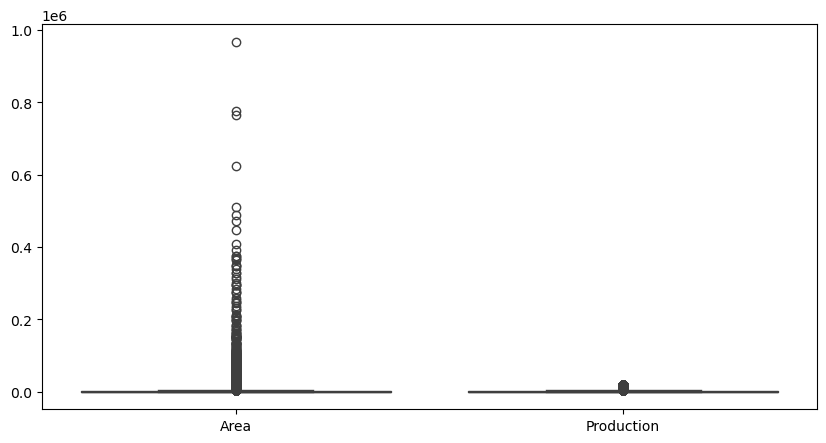

In [16]:
# detecting all the outliers using boxplot
plt.figure(figsize=(10,5))
sns.boxplot(data=df[['Area','Production']])
plt.show()


In [20]:
# handling the outliers using IQR method
Q1 = df[['Area','Production']].quantile(0.25)
Q3 = df[['Area','Production']].quantile(0.75)
IQR = Q3 - Q1

# Filter data
df = df[~((df[['Area','Production']] < (Q1 - 1.5 * IQR)) | 
          (df[['Area','Production']] > (Q3 + 1.5 * IQR))).any(axis=1)]
    

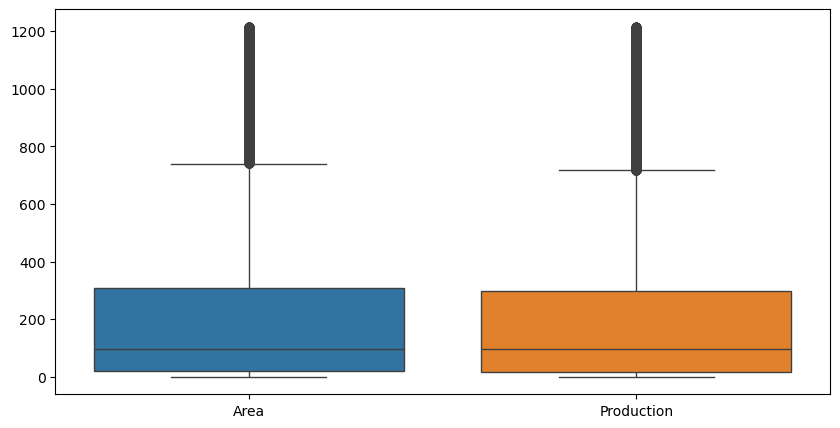

In [21]:
# checking for ouliers again using boxplot
plt.figure(figsize=(10,5))
sns.boxplot(data=df[['Area','Production']])
plt.show()

In [23]:
# converting the categorical variable into numerical variable using label encoding
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df['State_Name'] = le.fit_transform(df['State_Name'])
df['District_Name'] = le.fit_transform(df['District_Name'])
df['Season'] = le.fit_transform(df['Season'])
df['Crop'] = le.fit_transform(df['Crop'])

In [24]:
# defining the features and target variable
X=df.drop('Production', axis=1)
y=df['Production']


In [25]:
# train test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [26]:
# feature scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [27]:
# training the model using KNN algorithm
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train, y_train)


,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [28]:
# making predictions
y_pred = knn.predict(X_test)


In [31]:
# printing the predicted and actual values
print('Predicted values:', y_pred)
print('Actual values:', y_test.values)


Predicted values: [ 29.8 266.4 104.4 ...  34.  441.   28.4]
Actual values: [  19. 1098.  320. ...   20.  203.   78.]


In [29]:
# evaluating the model
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print('Mean Absolute Error:', mae)
print('Mean Squared Error:', mse)
print('R2 Score:', r2)


Mean Absolute Error: 102.89132325187515
Mean Squared Error: 31175.35700037212
R2 Score: 0.5796079249753081
